In [3]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-11 21:07:57.150434: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-11 21:07:57.150712: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fro

In [4]:
adata = sc.read("Moc_ref_cluster_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 21116 × 2500
    obs: 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden', 'Neutrophils_score', 'CD8_T_cells_score', 'Macrophages_score', 'Fibroblasts_score', 'DC_score', 'Cancer_cells_score', 'B_cells_score', 'CD4_T_cells_score', 'Monocytes_score', 'NK_cells_score', 'Endothelial_cells_score', 'cell_type', 'cluster_annotation'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [72]:
adata.obs['batch']

AAACCCAAGCACTCGC-1-CT_1     control 1
AAACCCAAGGATTCAA-1-CT_1     control 1
AAACCCAGTACTTGTG-1-CT_1     control 1
AAACCCATCACCATAG-1-CT_1     control 1
AAACGAACAACCGGAA-1-CT_1     control 1
                              ...    
TTTGGTTTCCTCTAAT-1-ASO_3        ASO 3
TTTGGTTTCTGTCCGT-1-ASO_3        ASO 3
TTTGTTGAGTGCGACA-1-ASO_3        ASO 3
TTTGTTGGTCCAGGTC-1-ASO_3        ASO 3
TTTGTTGGTTCACGAT-1-ASO_3        ASO 3
Name: batch, Length: 21116, dtype: category
Categories (6, object): ['ASO 1', 'ASO 2', 'ASO 3', 'control 1', 'control 2', 'control 3']

In [79]:
adta_sub = adata[adata.obs['batch']=='control 2'] 
adta_sub.obs['cluster_annotation'].value_counts()

cluster_annotation
nan                    1083
Neutrophil_N2           253
CD4_Treg                176
Neutrophil_undiff       161
Cancer_inflamed         134
Cancer_mesenchymal      126
Neutrophil_N1           118
CD8_central_memory      101
Cancer_classical         97
Mac_M1                   57
CD4_progenitor           54
CD8_effector_memory      50
Mac_M2                   43
CD8_progenitor           37
CD8_exhausted            33
CD4_Th1                  22
Name: count, dtype: int64

In [76]:
adta_sub.obs['cluster_annotation']

AAACCCACATGTGACT-1-ASO_2                Mac_M2
AAACCCATCAATCAGC-1-ASO_2         CD8_exhausted
AAACGAAAGGCATCTT-1-ASO_2         Neutrophil_N2
AAACGAACAAGCACAG-1-ASO_2                   nan
AAACGCTAGCGTGCCT-1-ASO_2    Cancer_mesenchymal
                                   ...        
TTTGGTTGTGCTGTCG-1-ASO_2                   nan
TTTGTTGAGCCATTCA-1-ASO_2         CD8_exhausted
TTTGTTGAGGTAATCA-1-ASO_2                Mac_M2
TTTGTTGGTGTGTCCG-1-ASO_2       Cancer_inflamed
TTTGTTGTCACTGTTT-1-ASO_2              CD4_Treg
Name: cluster_annotation, Length: 3233, dtype: category
Categories (16, object): ['CD4_Th1', 'CD4_Treg', 'CD4_progenitor', 'CD8_central_memory', ..., 'Neutrophil_N1', 'Neutrophil_N2', 'Neutrophil_undiff', 'nan']

In [5]:
import liana as li
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [6]:
li.rs.show_resources()

['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

In [7]:
li.mt.rank_aggregate(
    adata,
    groupby='cell_type',
    resource_name='mouseconsensus',
    use_raw=False,
    expr_prop=0.01  # lower threshold, default is 0.1
)

In [8]:
adata.obs['cell_type'].value_counts()

cell_type
Neutrophils          6024
DC                   4378
Cancer_cells         3430
CD8_T_cells          1727
CD4_T_cells          1405
Fibroblasts          1294
Macrophages           915
Monocytes             813
B_cell                478
Endothelial_cells     354
NK_cells              298
Name: count, dtype: int64

In [9]:
adata.obs['cluster_annotation'].value_counts()

cluster_annotation
Neutrophil_N2          3094
Neutrophil_N1          2254
Cancer_inflamed        1653
Cancer_mesenchymal      952
CD4_Treg                929
Cancer_classical        825
Neutrophil_undiff       676
CD8_central_memory      585
Mac_M1                  461
Mac_M2                  454
CD8_effector_memory     439
CD8_exhausted           367
CD8_progenitor          336
CD4_progenitor          290
CD4_Th1                 186
Name: count, dtype: int64

In [10]:
type_state = {'CD4_T_cells': ['CD4_Th1', 'CD4_Treg', 'CD4_progenitor'],
             'CD8_T_cells': ['CD8_exhausted', 'CD8_progenitor', 'CD8_central_memory', 'CD8_effector_memory'],
             'Cancer_cells': ['Cancer_inflamed', 'Cancer_classical', 'Cancer_mesenchymal'],}

In [11]:
print(adata.uns['liana_res']['source'].unique())
print(adata.uns['liana_res']['target'].unique())

['Fibroblasts' 'Endothelial_cells' 'Macrophages' 'Neutrophils' 'Monocytes'
 'DC' 'Cancer_cells' 'B_cell' 'CD4_T_cells' 'NK_cells' 'CD8_T_cells']
['Neutrophils' 'Monocytes' 'DC' 'B_cell' 'CD4_T_cells' 'Macrophages'
 'Endothelial_cells' 'CD8_T_cells' 'NK_cells' 'Fibroblasts' 'Cancer_cells']


In [12]:
liana_res = adata.uns['liana_res']
ref_df = liana_res[
    (liana_res['source'].isin(['CD4_T_cells', 'CD8_T_cells', 'Macrophages', 'Neutrophils'])) &
    (liana_res['target'] == 'Cancer_cells')
].copy()
ref_df = ref_df.sort_values('lrscore', ascending=False)
ref_df

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
14264,Macrophages,Cancer_cells,Fn1,Cd44,0.953706,0.250,0.770248,0.033689,-0.400687,0.008696,0.907384,0.662993,0.024591
19353,Neutrophils,Cancer_cells,Mmp9,Cd44,0.850784,0.001,0.650762,0.203403,0.179840,0.042405,0.900054,0.165766,0.034772
14292,Macrophages,Cancer_cells,Igf1,Igf1r,0.777858,0.000,0.596216,0.717569,0.266123,0.052535,0.896047,0.010109,0.043473
19339,Neutrophils,Cancer_cells,Il1b,Il1r1_Il1rap,1.793491,0.000,0.594386,0.494173,1.539279,0.039229,0.895904,0.010109,0.005107
19236,Neutrophils,Cancer_cells,Alcam,Chl1,0.885477,0.000,0.409693,0.621011,1.232089,0.071482,0.877230,0.010109,0.030695
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2091,CD4_T_cells,Cancer_cells,Ncam1,Cacna1c,0.005524,1.000,0.000029,-0.202449,-0.192546,0.000051,0.056262,1.000000,0.050440
3684,CD8_T_cells,Cancer_cells,Pf4,Grm7,0.005337,1.000,0.000023,-0.128384,-0.195275,0.000279,0.051312,1.000000,0.033398
3621,CD8_T_cells,Cancer_cells,Cxcl12,Grm7,0.005180,1.000,0.000023,-0.116909,-0.133599,0.000236,0.050296,1.000000,0.029456
3620,CD8_T_cells,Cancer_cells,Cxcl12,Cd4,0.005147,1.000,0.000022,-0.192234,-0.213705,0.000023,0.049776,1.000000,0.027265


In [13]:
ref_df.head(50).to_csv('LR_pairs.csv')


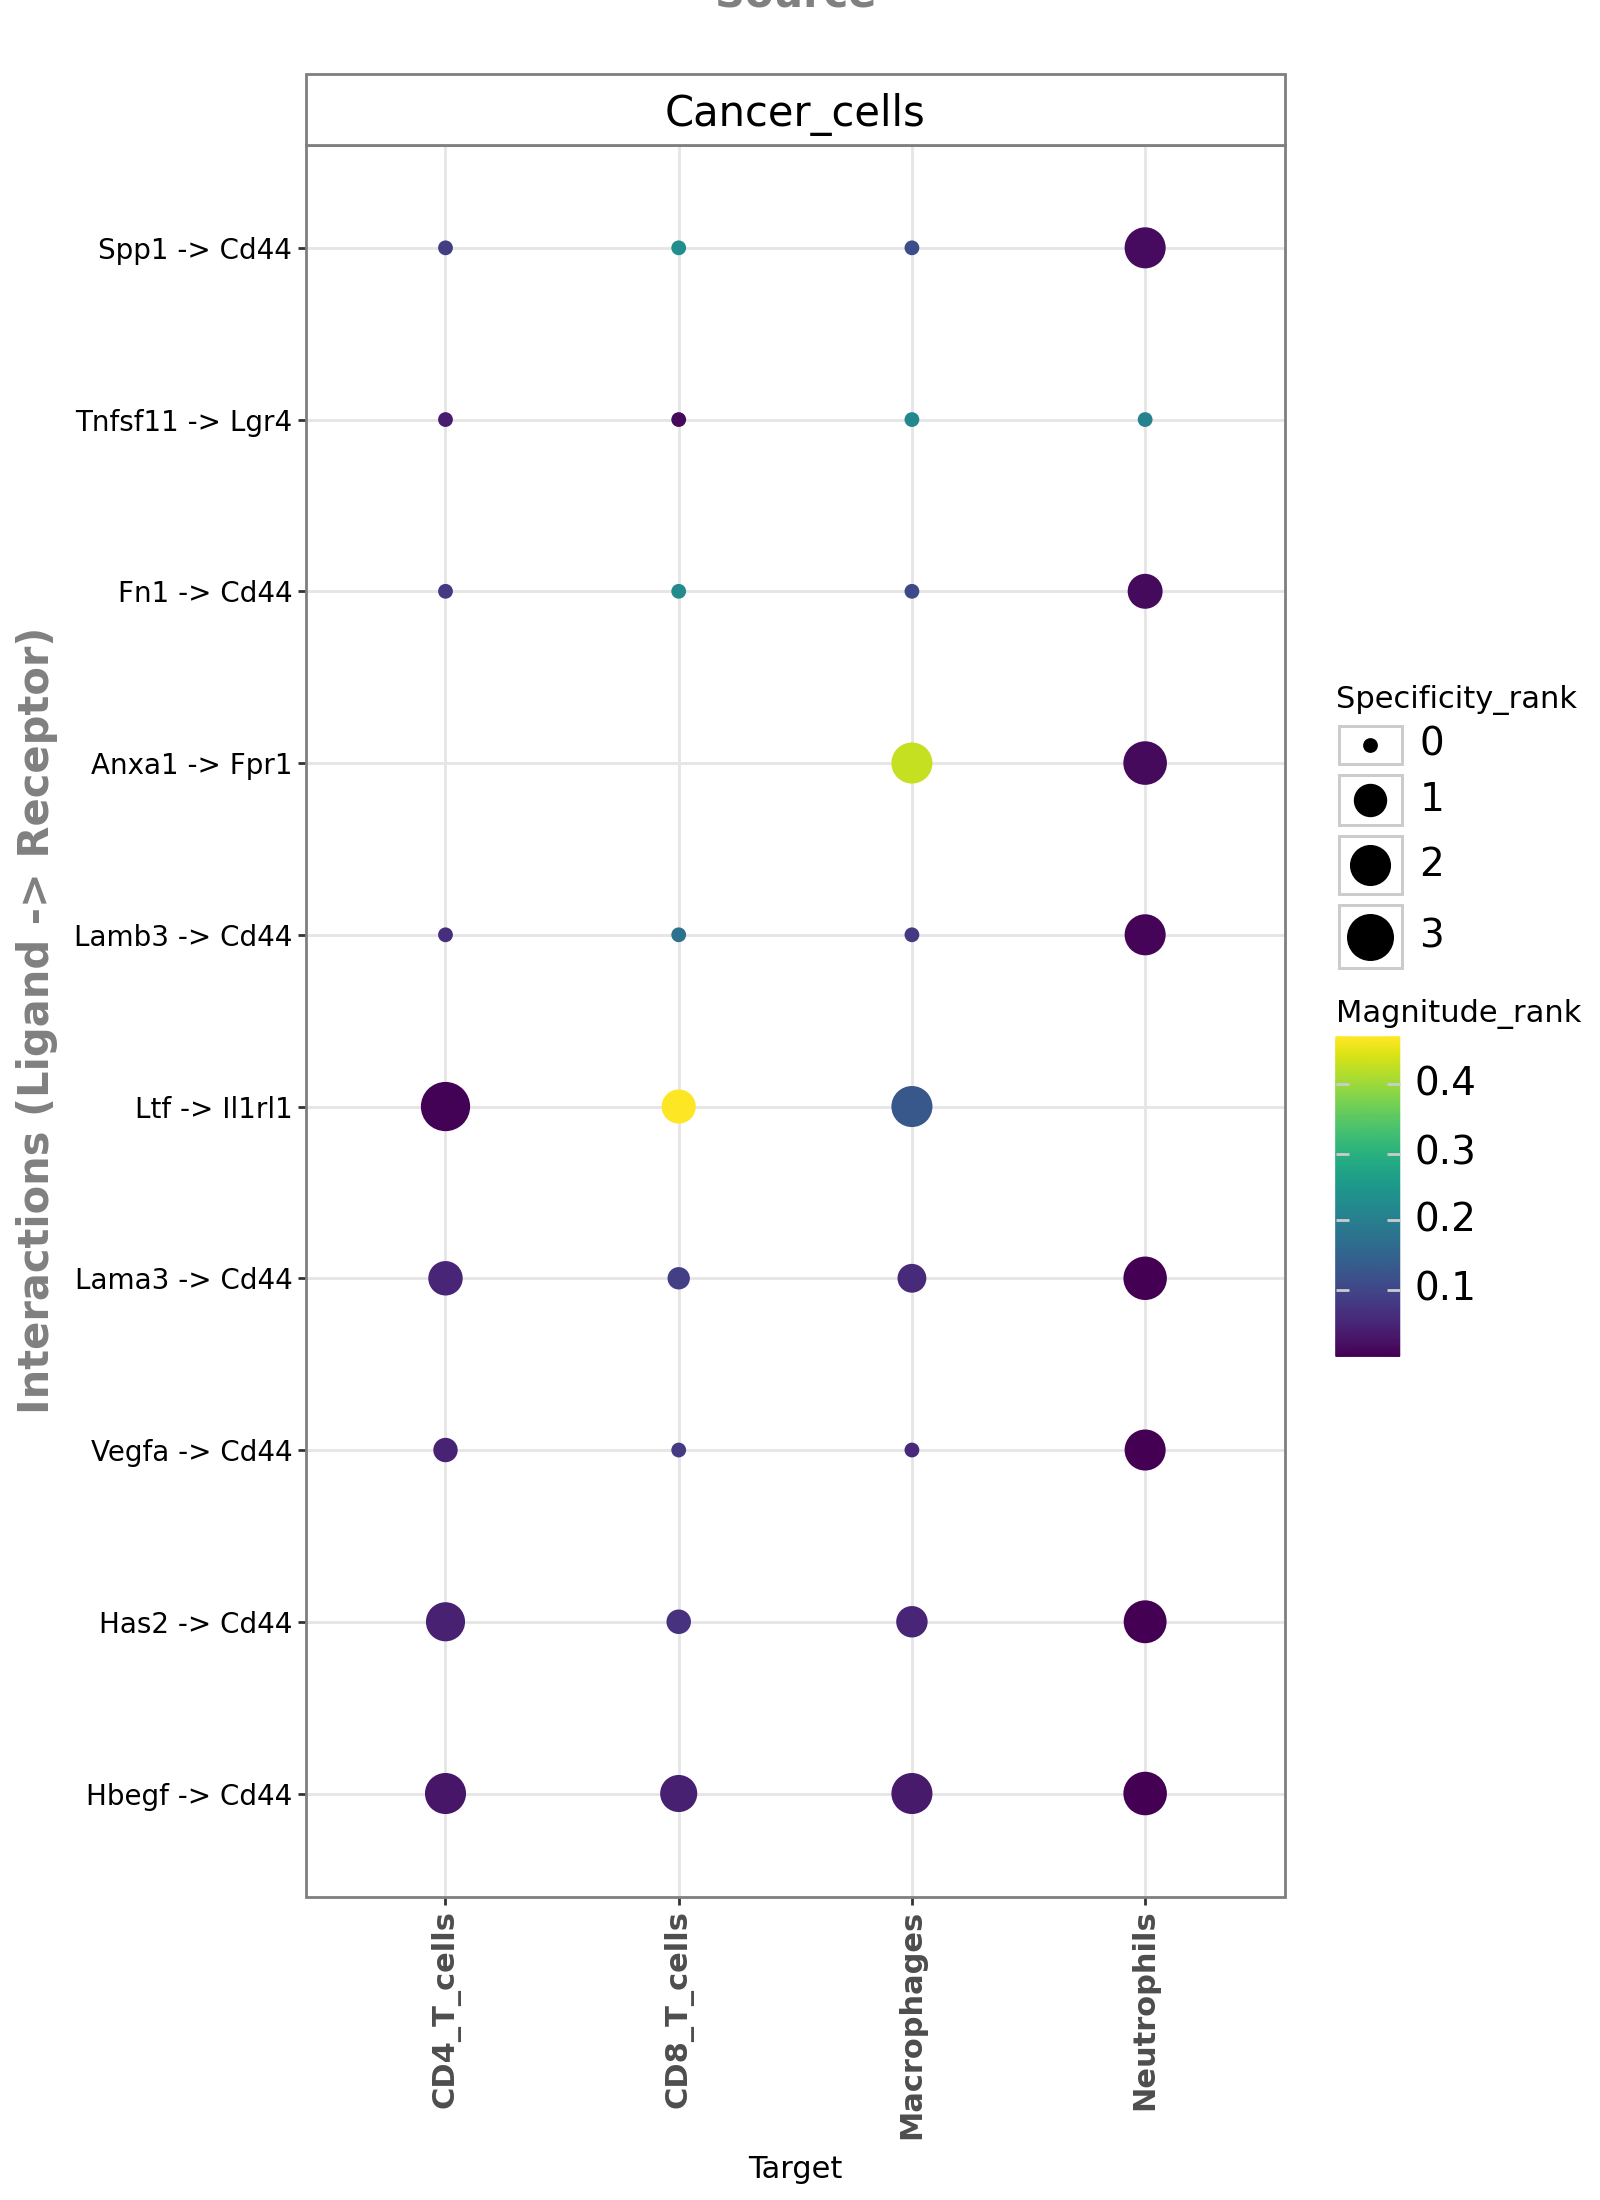

In [62]:
li.pl.dotplot(
    adata,
    colour='magnitude_rank',
    size='specificity_rank',
    source_labels=['Cancer_cells'],
    target_labels=['CD4_T_cells','CD8_T_cells','Macrophages','Neutrophils'],
    inverse_size=True,
    top_n=10,
    orderby='magnitude_rank',
    orderby_ascending=True,
    figure_size=(8, 11),

)


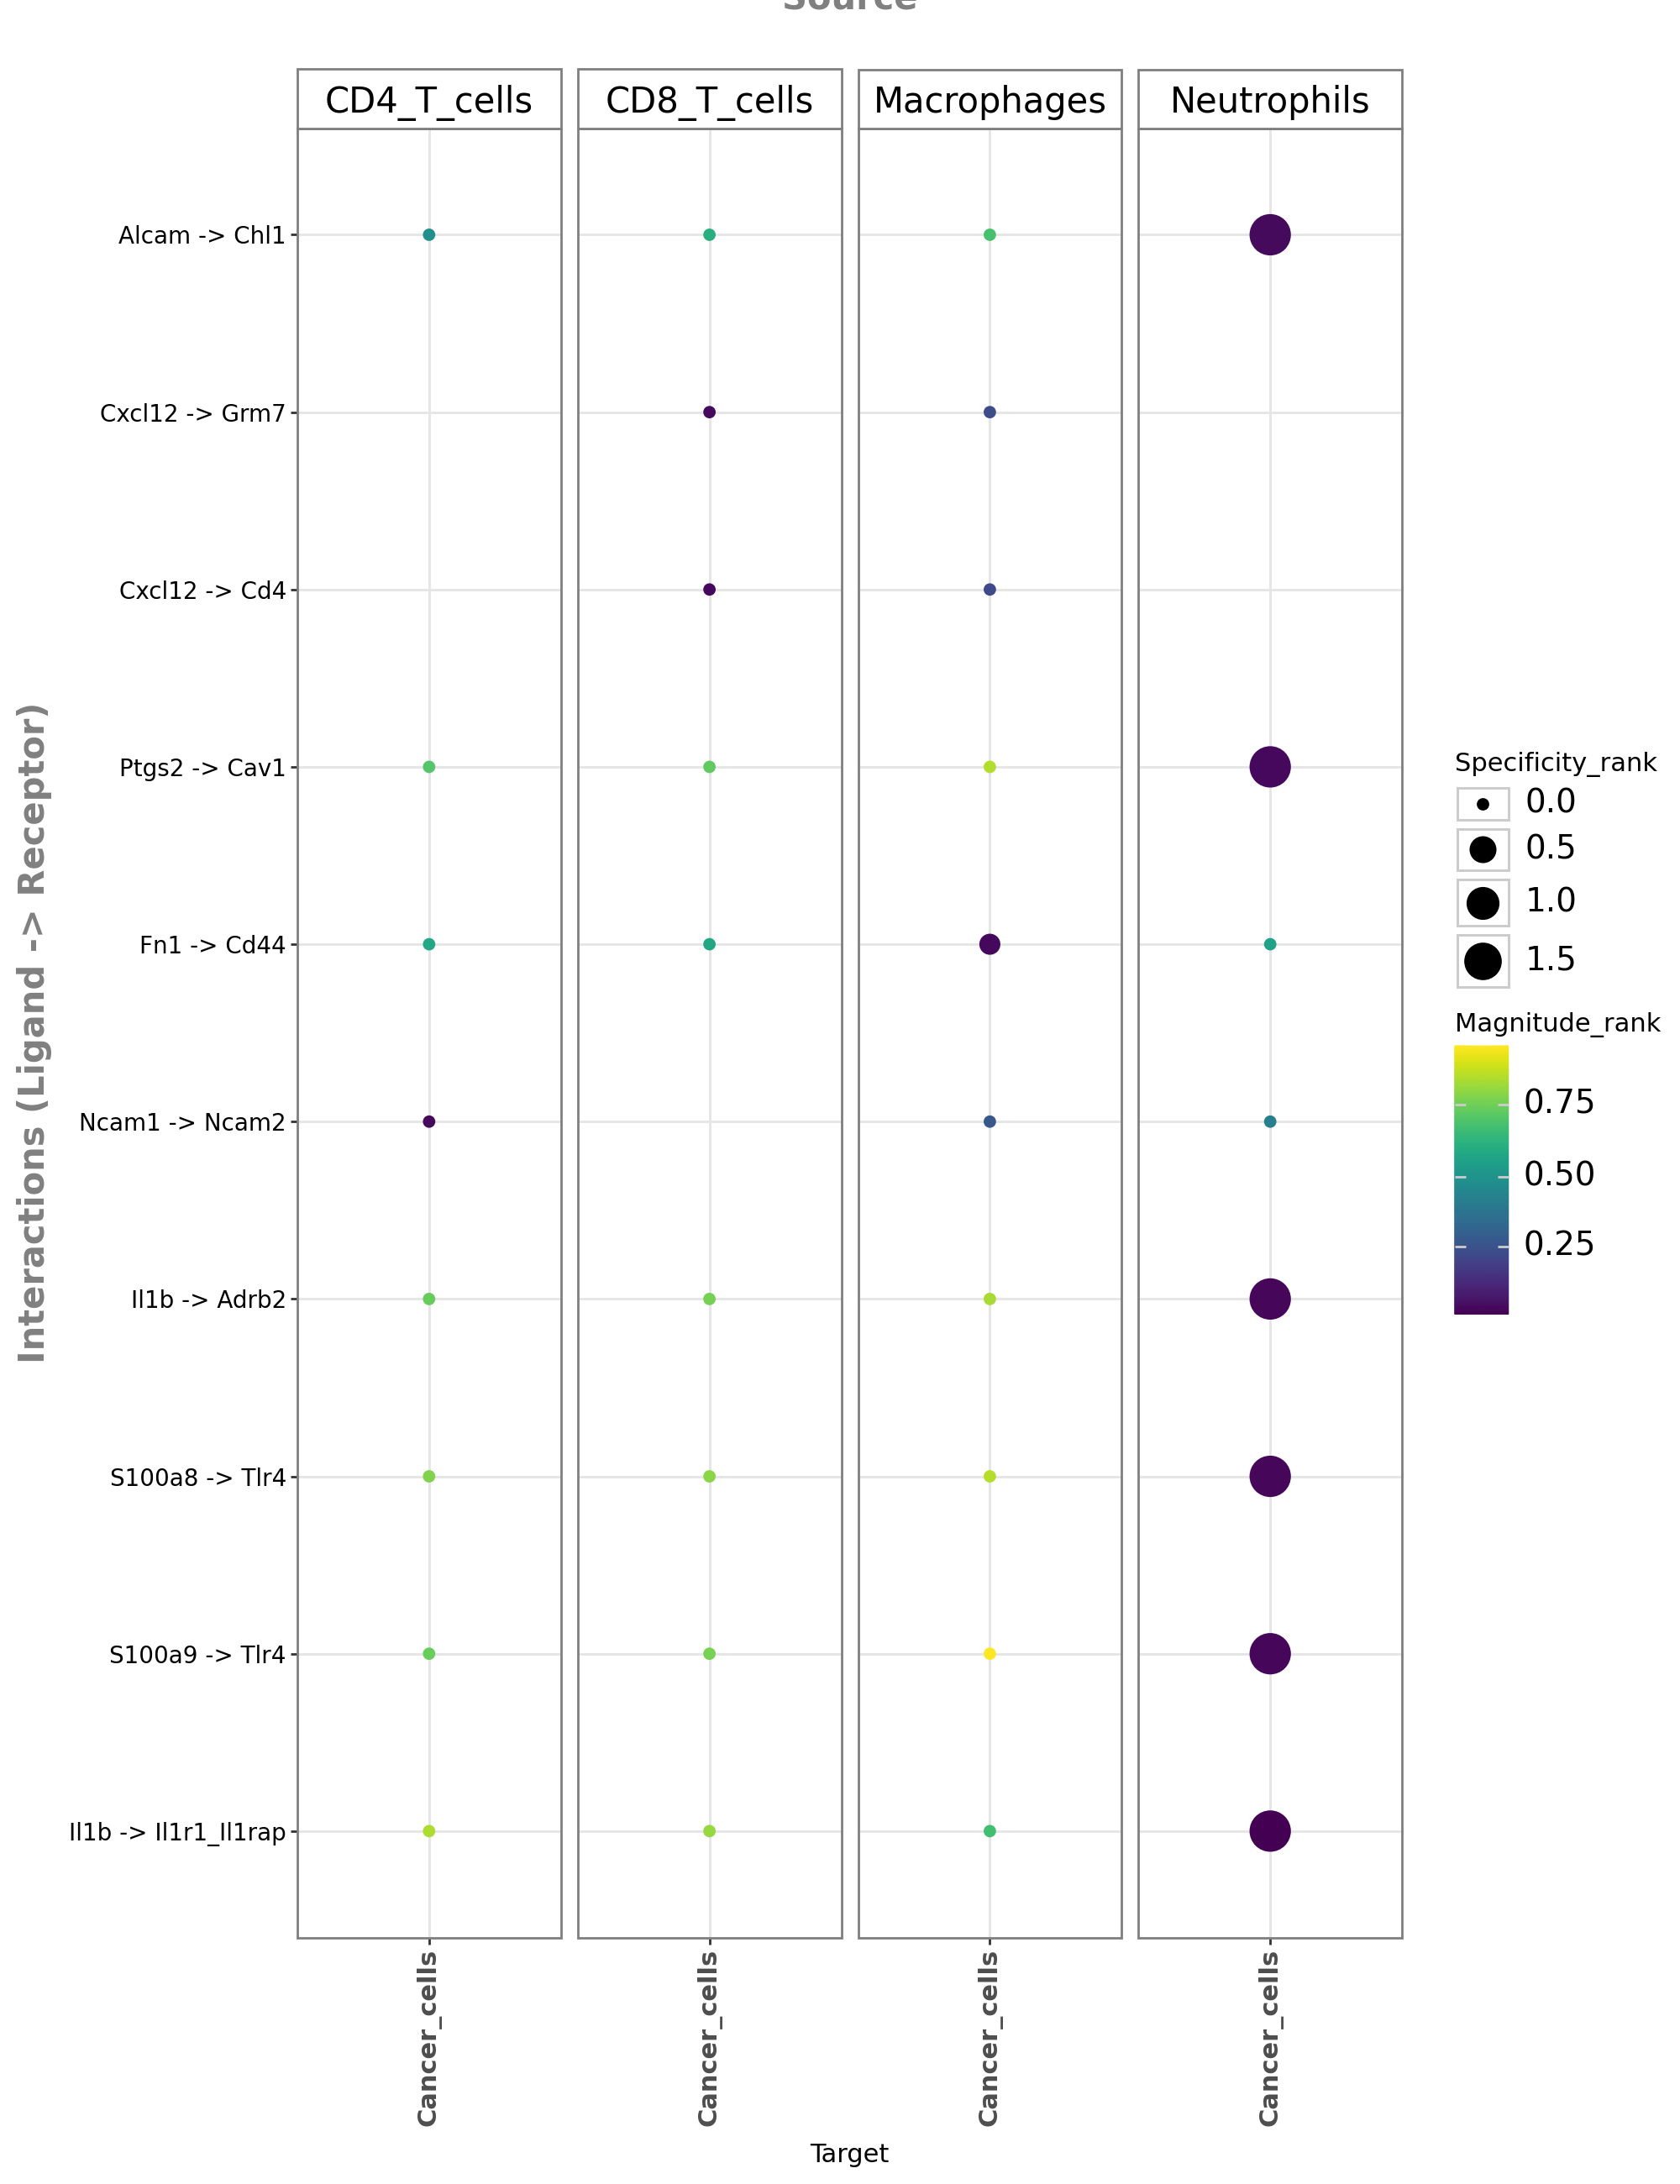

In [56]:
li.pl.dotplot(
    adata,
    colour='magnitude_rank',
    size='specificity_rank',
    source_labels=['CD4_T_cells','CD8_T_cells','Macrophages','Neutrophils'],
    target_labels=['Cancer_cells'],
    inverse_size=True,
    top_n=10,
    orderby='magnitude_rank',
    orderby_ascending=True,
    figure_size=(10,13)
)

## check the L-R expression level by states

In [16]:
# Per row: ligand avg expr in each source cluster_annotation, receptor avg expr in each target cluster_annotation
# Subsets are defined by obs['cell_type'] (source/target) then obs['cluster_annotation'] (e.g. N1_antitumor, Cancer_inflamed)

def _avg_expr_complex_in_mask(adata, gene_list, mask):
    genes_found = [g for g in gene_list if g in adata.var_names]
    if mask.sum() == 0 or not genes_found:
        return np.nan
    X = adata[mask, genes_found].X
    if hasattr(X, 'toarray'):
        X = X.toarray()
    return float(np.mean(X))

all_clusters = sorted(adata.obs['cluster_annotation'].astype(str).unique().tolist())
lig_cols = [f'lig_avg_{c}' for c in all_clusters]
rec_cols = [f'rec_avg_{c}' for c in all_clusters]

rows_out = []
for idx, row in ref_df.iterrows():
    source_label = row['source']
    target_label = row['target']
    lig_genes = str(row['ligand_complex']).split('_')
    rec_genes = str(row['receptor_complex']).split('_')

    # Source subsets = cluster_annotations that appear in cells with cell_type == source
    source_cells = adata.obs['cell_type'] == source_label
    source_subsets = adata.obs.loc[source_cells, 'cluster_annotation'].unique()

    # Target subsets = cluster_annotations in cells with cell_type == target
    target_cells = adata.obs['cell_type'] == target_label
    target_subsets = adata.obs.loc[target_cells, 'cluster_annotation'].unique()

    out = {**row.to_dict()}
    for c in all_clusters:
        out[f'lig_avg_{c}'] = np.nan
        out[f'rec_avg_{c}'] = np.nan
    for c in source_subsets:
        c = str(c)
        mask = source_cells & (adata.obs['cluster_annotation'].astype(str) == c)
        out[f'lig_avg_{c}'] = _avg_expr_complex_in_mask(adata, lig_genes, mask.values)
    for c in target_subsets:
        c = str(c)
        mask = target_cells & (adata.obs['cluster_annotation'].astype(str) == c)
        out[f'rec_avg_{c}'] = _avg_expr_complex_in_mask(adata, rec_genes, mask.values)
    rows_out.append(out)

ref_df_by_subset = pd.DataFrame(rows_out)
ref_df_by_subset.head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,...,lig_avg_Mac_M2,rec_avg_Mac_M2,lig_avg_Neutrophil_N1,rec_avg_Neutrophil_N1,lig_avg_Neutrophil_N2,rec_avg_Neutrophil_N2,lig_avg_Neutrophil_undiff,rec_avg_Neutrophil_undiff,lig_avg_nan,rec_avg_nan
0,Macrophages,Cancer_cells,Fn1,Cd44,0.953706,0.250,0.770248,0.033689,-0.400687,0.008696,...,1.071457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Neutrophils,Cancer_cells,Mmp9,Cd44,0.850784,0.001,0.650762,0.203403,0.179840,0.042405,...,NaN,NaN,1.447549,NaN,1.056385,NaN,0.328810,NaN,NaN,NaN
2,Macrophages,Cancer_cells,Igf1,Igf1r,0.777858,0.000,0.596216,0.717569,0.266123,0.052535,...,1.154090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Neutrophils,Cancer_cells,Il1b,Il1r1_Il1rap,1.793491,0.000,0.594386,0.494173,1.539279,0.039229,...,NaN,NaN,3.344510,NaN,3.858388,NaN,1.601215,NaN,NaN,NaN
4,Neutrophils,Cancer_cells,Alcam,Chl1,0.885477,0.000,0.409693,0.621011,1.232089,0.071482,...,NaN,NaN,1.112903,NaN,1.572734,NaN,2.434105,NaN,NaN,NaN


In [66]:
ref_df_by_subset.to_csv('LR_score_by_state.csv')

In [17]:
# Subsets: cells where cluster_annotation has same prefix (before first '_') as source/target
obs = adata.obs
obs_prefix = obs['cluster_annotation'].astype(str).str.split('_').str[0]

def _avg_expr_in_subset(adata, gene_names, mask):
    """Mean expression of genes (complex) in cells matching mask. Returns mean over genes then over cells."""
    if mask.sum() == 0:
        return np.nan
    genes_found = [g for g in gene_names if g in adata.var_names]
    if not genes_found:
        return np.nan
    # adata.X: (n_obs, n_vars); rows = cells, cols = genes
    X = adata[mask, genes_found].X
    if hasattr(X, 'toarray'):
        X = X.toarray()
    return float(np.mean(X))

def _subset_mask(obs, obs_prefix, label):
    prefix = label.split('_')[0]
    mask = (obs_prefix == prefix)
    if mask.sum() == 0:
        mask = (obs['cell_type'] == label)
    return mask.values

ligand_avg_source = []
receptor_avg_target = []
for _, row in ref_df.iterrows():
    source_mask = _subset_mask(obs, obs_prefix, row['source'])
    target_mask = _subset_mask(obs, obs_prefix, row['target'])
    lig_genes = str(row['ligand_complex']).split('_')
    rec_genes = str(row['receptor_complex']).split('_')
    ligand_avg_source.append(_avg_expr_in_subset(adata, lig_genes, source_mask))
    receptor_avg_target.append(_avg_expr_in_subset(adata, rec_genes, target_mask))

ref_df = ref_df.assign(ligand_avg_source=ligand_avg_source, receptor_avg_target=receptor_avg_target)
ref_df.head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,ligand_avg_source,receptor_avg_target
14264,Macrophages,Cancer_cells,Fn1,Cd44,0.953706,0.250,0.770248,0.033689,-0.400687,0.008696,0.907384,0.662993,0.024591,1.326944,0.580467
19353,Neutrophils,Cancer_cells,Mmp9,Cd44,0.850784,0.001,0.650762,0.203403,0.179840,0.042405,0.900054,0.165766,0.034772,1.121100,0.580467
14292,Macrophages,Cancer_cells,Igf1,Igf1r,0.777858,0.000,0.596216,0.717569,0.266123,0.052535,0.896047,0.010109,0.043473,0.871913,0.683802
19339,Neutrophils,Cancer_cells,Il1b,Il1r1_Il1rap,1.793491,0.000,0.594386,0.494173,1.539279,0.039229,0.895904,0.010109,0.005107,3.412816,0.179262
19236,Neutrophils,Cancer_cells,Alcam,Chl1,0.885477,0.000,0.409693,0.621011,1.232089,0.071482,0.877230,0.010109,0.030695,1.497340,0.273614


In [18]:
# All unique subsets (cluster_annotation prefix before first '_')
subsets = sorted(obs_prefix.unique().tolist())

# All unique ligand and receptor genes from ref_df
all_ligands = set()
all_receptors = set()
for _, row in ref_df.iterrows():
    all_ligands.update(str(row['ligand_complex']).split('_'))
    all_receptors.update(str(row['receptor_complex']).split('_'))
all_genes = sorted((all_ligands | all_receptors) & set(adata.var_names))

def _avg_expr_single_gene(adata, gene, mask):
    if mask.sum() == 0 or gene not in adata.var_names:
        return np.nan
    x = adata[mask, gene].X
    if hasattr(x, 'toarray'):
        x = x.toarray()
    return float(np.mean(x))

# Build matrix: rows = genes, columns = subsets
expr_rows = []
for gene in all_genes:
    row_dict = {'gene': gene, 'type': 'ligand' if gene in all_ligands else 'receptor'}
    if gene in all_ligands and gene in all_receptors:
        row_dict['type'] = 'both'
    for sub in subsets:
        mask = (obs_prefix == sub).values
        row_dict[sub] = _avg_expr_single_gene(adata, gene, mask)
    expr_rows.append(row_dict)

expr_all_subsets_df = pd.DataFrame(expr_rows).set_index('gene')
# Reorder: type column first, then subset columns
cols = ['type'] + subsets
expr_all_subsets_df = expr_all_subsets_df[cols]
expr_all_subsets_df

,type,CD4,CD8,Cancer,Mac,Neutrophil,nan
gene,,,,,,,
Ackr3,receptor,0.005715,0.002236,0.180892,0.014350,0.005149,0.103617
Adam12,ligand,0.180211,0.005877,0.119173,0.013011,0.009196,0.151084
Adm,ligand,0.002382,0.000966,0.007946,0.004795,0.017563,0.071985
Adrb2,receptor,0.043035,0.029198,0.082612,0.145035,0.310650,0.075637
Alcam,ligand,0.460614,0.336833,0.355983,0.277380,1.497340,0.480047
...,...,...,...,...,...,...,...
Unc5c,receptor,0.002559,0.000967,0.008035,0.006292,0.001356,0.016740
Unc5d,receptor,0.004601,0.006608,0.004779,0.021110,0.007104,0.011297
Vcan,ligand,0.003227,0.006206,0.088040,0.053780,0.014994,0.274973


# DEA

### This check Differential expression between conditions (usually different samples)

In [37]:
import liana as li
import decoupler as dc
import omnipath as op

# adata.obs['sample_id'] = 'E4S'
adata.obs['condition'] = adata.obs['batch'].astype(str).str.startswith('control').map({True: 'CT', False: 'ASO'})
adata.obs['condition']

AAACCCAAGCACTCGC-1-CT_1      CT
AAACCCAAGGATTCAA-1-CT_1      CT
AAACCCAGTACTTGTG-1-CT_1      CT
AAACCCATCACCATAG-1-CT_1      CT
AAACGAACAACCGGAA-1-CT_1      CT
                           ... 
TTTGGTTTCCTCTAAT-1-ASO_3    ASO
TTTGGTTTCTGTCCGT-1-ASO_3    ASO
TTTGTTGAGTGCGACA-1-ASO_3    ASO
TTTGTTGGTCCAGGTC-1-ASO_3    ASO
TTTGTTGGTTCACGAT-1-ASO_3    ASO
Name: condition, Length: 21116, dtype: object

In [38]:
# pdata = dc.pp.pseudobulk(
#     adata,
#     sample_col='condition',
#     groups_col='cell_type',
#     # layer='counts',
#     mode='sum',
#     skip_checks=True
# )
# pdata

In [39]:
import omnipath as op
import plotnine as p9
import decoupler as dc

#  dea_df should have genes ranked by how differentially expressed 
#  they are between conditions within each cluster

In [67]:
# Run rank_genes_groups for each leiden cluster
# groupby = 'cell_type' 
# groupby = 'cluster_annotation'
groupby = 'condition'

sc.tl.rank_genes_groups(adata, groupby, method='wilcoxon')

# Extract top 20 genes per cluster into a DataFrame
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
n_genes = 30

df_top_genes = pd.DataFrame({
    group: result['names'][group][:n_genes] for group in groups
})

# Also create a version with scores and pvals
df_detailed = pd.DataFrame()
for group in groups:
    temp_df = pd.DataFrame({
        groupby: group,
        'gene': result['names'][group][:n_genes],
        'scores': result['scores'][group][:n_genes],
        'logfoldchanges': result['logfoldchanges'][group][:n_genes],
        'pvals': result['pvals'][group][:n_genes],
        'pvals_adj': result['pvals_adj'][group][:n_genes],
    })
    df_detailed = pd.concat([df_detailed, temp_df], ignore_index=True)

# Filter df_detailed so it only contains genes present in adata.var_names
df_detailed = df_detailed[df_detailed['gene'].isin(adata.var_names)].copy()
# Set the index to 'gene'
df_detailed.set_index('gene', inplace=True)

In [68]:
df_detailed = df_detailed.dropna(subset=[groupby])
df_detailed

,condition,scores,logfoldchanges,pvals,pvals_adj
gene,,,,,
Gbp2,ASO,9.767544,0.470297,1.551679e-22,4.848996e-20
Ighg1,ASO,9.405741,1.051921,5.166511e-21,1.435142e-18
Csf1,ASO,8.368336,0.463042,5.843758e-17,1.328127e-14
Jdp2,ASO,8.031253,0.426846,9.648246e-16,1.855432e-13
Isg15,ASO,7.281826,0.325985,3.293304e-13,4.843094e-11
Gsto1,ASO,7.027049,0.333409,2.109475e-12,2.929826e-10
Etl4,ASO,6.969872,0.633648,3.172291e-12,4.174067e-10
Nupr1,ASO,6.835711,0.531533,8.159901e-12,1.019988e-09
Hsph1,ASO,6.627347,0.279302,3.417752e-11,3.883809e-09


In [69]:
adata.obs[groupby] = adata.obs[groupby].astype(str)

In [71]:
lr_res = li.multi.df_to_lr(adata,
                           dea_df= df_detailed,
                           resource_name='mouseconsensus', # NOTE: uses HUMAN gene symbols!
                           expr_prop=0.01, # calculated for adata as passed - used to filter interactions
                           groupby= 'cluster_annotation',
                           stat_keys=['scores', 'pvals', 'pvals_adj'],
                           use_raw=False,
                           complex_col='scores', # NOTE: we use the Wald Stat to deal with complexes
                           verbose=True,
                           return_all_lrs=False,
                           )

ValueError: groupby must match a column in both adata.obs and dea_df

In [ ]:
lr_res.head()

In [ ]:
lr_res = lr_res.sort_values("interaction_scores", ascending=False, key=abs)
lr_res.head()

In [ ]:
# Let's visualize how this looks like for all interactions  (across all cell types)
lr_res = lr_res.sort_values("interaction_scores", ascending=False)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(lr_res['interaction_scores'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Interaction Scores')
plt.ylabel('Frequency')
plt.title('Histogram of Interaction Scores')
plt.show()

In [ ]:
from plotnine import theme

p = li.pl.tileplot(liana_res=lr_res,
               fill = 'expr',
               label='pvals_adj',
               label_fun = lambda x: '*' if x < 0.05 else np.nan,
               top_n=30,
               orderby = 'interaction_scores',
               orderby_ascending = False,
               orderby_absolute = False,
               source_title='Ligand',
               target_title='Receptor',
               )

p = p + theme(figure_size=(10, 8))
p

In [ ]:
print(lr_res['source'].unique())
print(lr_res['target'].unique())

In [ ]:
plot = li.pl.dotplot(liana_res=lr_res,
                     colour='interaction_scores',
                     size='ligand_pvals',
                     inverse_size=True,
                     orderby='interaction_scores',
                     orderby_ascending=False,
                     orderby_absolute=True,
                     source_labels=['Malign Epithelial','Neutrophil','M1 Mac'],
                     target_labels=['M1 Mac', 'Macrophage', 'M2 Mac'],
                     top_n=15,
                     size_range=(0.5, 4)
                     )
plot.show()

# DEA correct